<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Numerov_Method_Solver_for_Heat_Equation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

CC-BY-4.0 (Open Access)

In [4]:
!uv pip install numpy scipy matplotlib

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 104ms


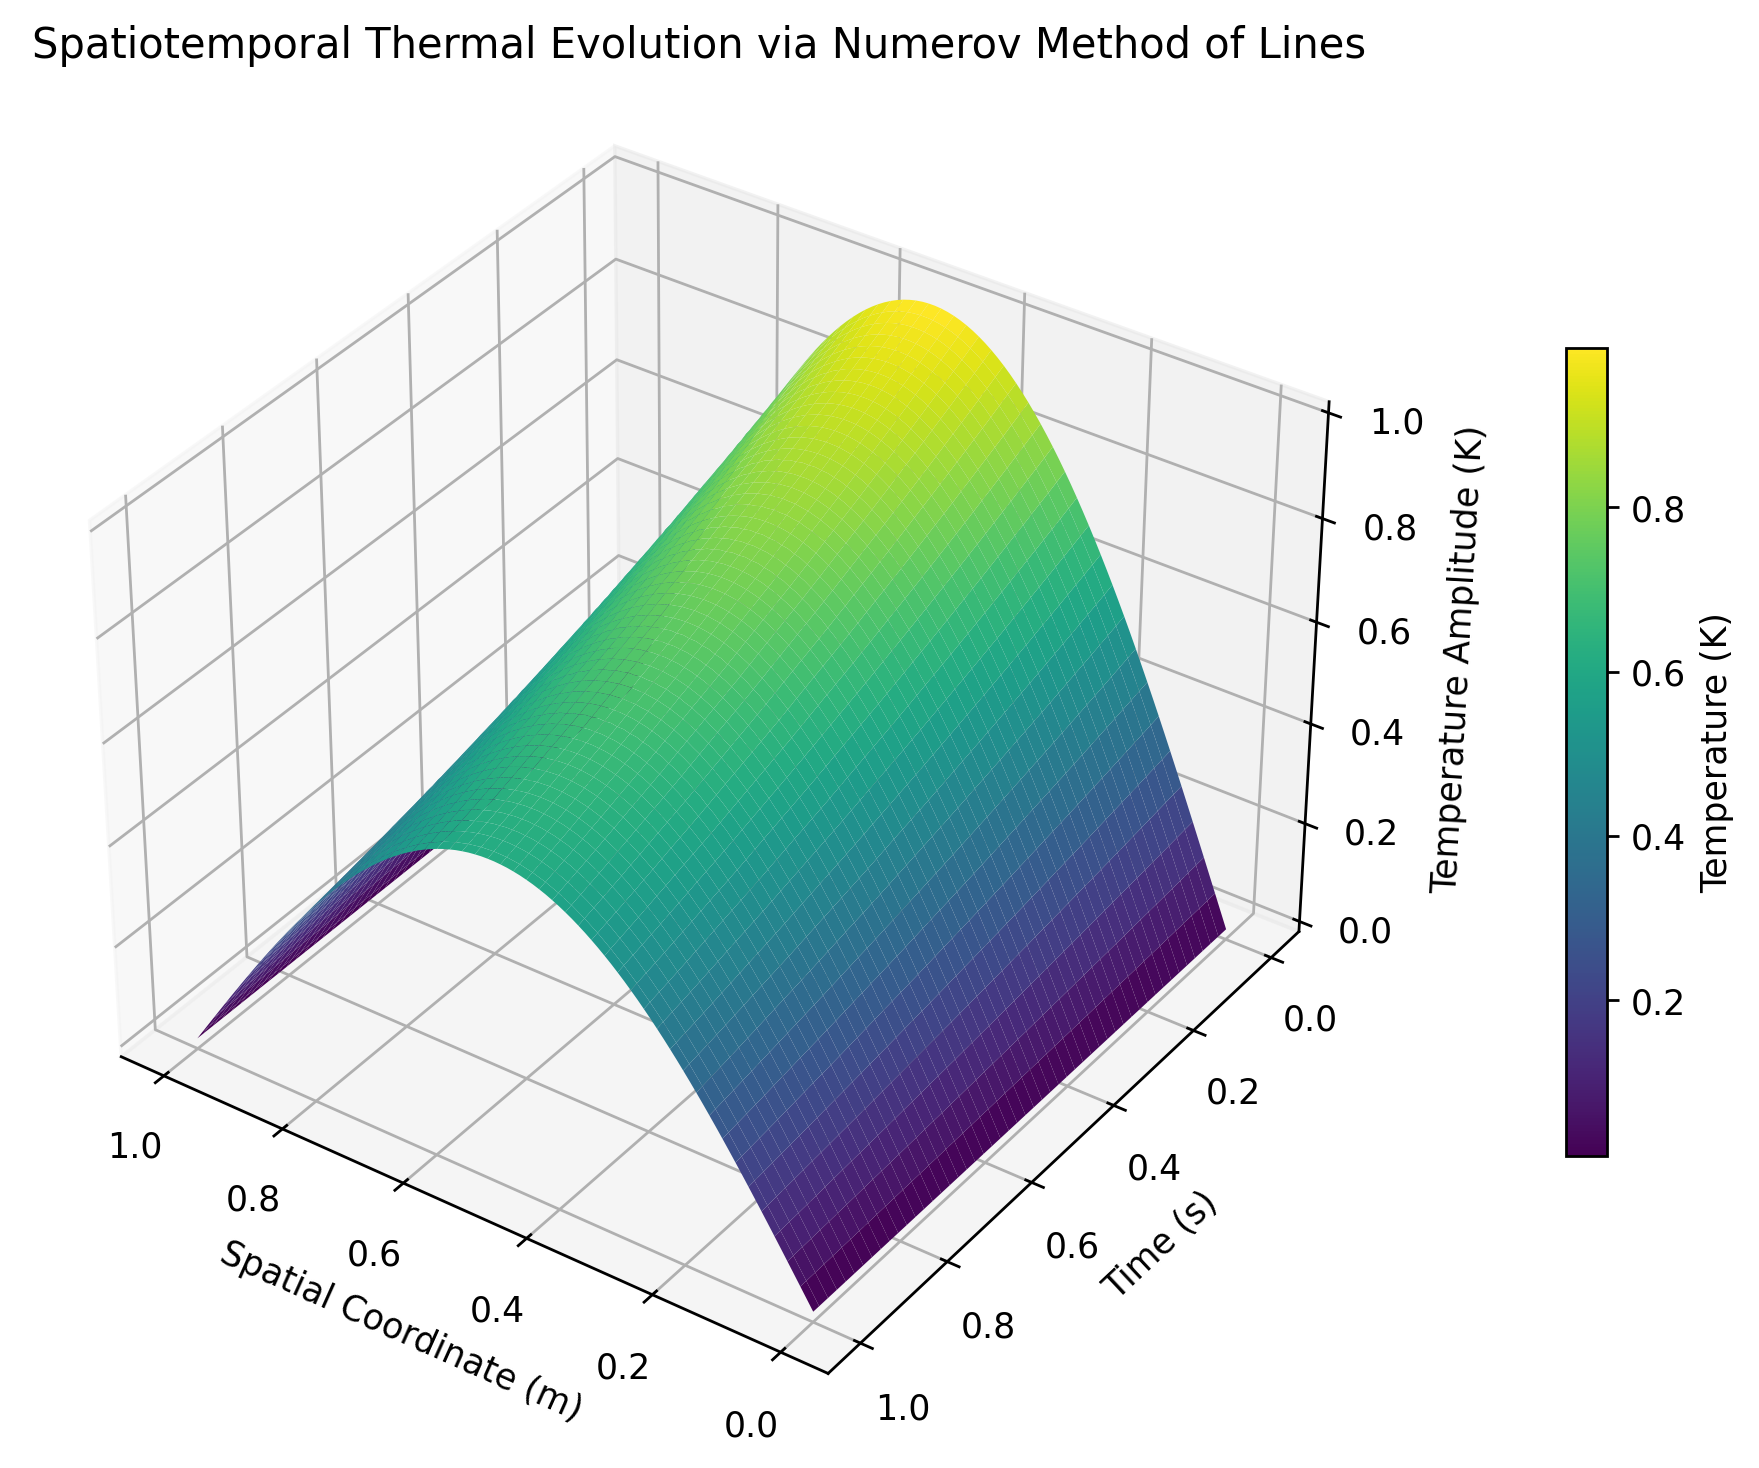

In [5]:
"""This script implements the Method of Lines using the Numerov scheme and generates a three-dimensional thermodynamic surface plot."""

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import factorized
from scipy.integrate import solve_ivp

# ---------------------------------------------------
# Simulation and Visualization Control Parameters
# ---------------------------------------------------
SPATIAL_POINTS: int = 100
DOMAIN_LENGTH: float = 1.0
THERMAL_DIFFUSIVITY: float = 0.05
TIME_START: float = 0.0
TIME_END: float = 1.0
TIME_STEPS: int = 150
COLOR_MAP: str = 'viridis'
ELEVATION_ANGLE: float = 35.0
AZIMUTHAL_ANGLE: float = 125.0

def main() -> None:
    """Executes the Numerov Method of Lines integration and projects the resulting matrix onto a three-dimensional surface plot."""
    plt.rcParams.update({
        'figure.dpi': 250,
        'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
        'font.weight': 'normal'
    })

    dx = DOMAIN_LENGTH / (SPATIAL_POINTS - 1)
    spatial_grid = np.linspace(0.0, DOMAIN_LENGTH, SPATIAL_POINTS)

    # Initialize the thermodynamic state vector using a smooth sinusoidal boundary perturbation
    u_initial = np.sin(np.pi * spatial_grid)
    u_interior_initial = u_initial[1:-1]
    interior_size = SPATIAL_POINTS - 2

    # ---------------------------------------------------
    # Matrix Operator Assembly
    # ---------------------------------------------------
    m_diagonal = np.full(interior_size, 10.0 / 12.0)
    m_off_diagonal = np.full(interior_size - 1, 1.0 / 12.0)
    mass_matrix = diags(
        [m_off_diagonal, m_diagonal, m_off_diagonal],
        offsets=[-1, 0, 1],
        format='csc'
    )

    k_diagonal = np.full(interior_size, -2.0)
    k_off_diagonal = np.full(interior_size - 1, 1.0)
    stiffness_matrix = diags(
        [k_off_diagonal, k_diagonal, k_off_diagonal],
        offsets=[-1, 0, 1],
        format='csc'
    )

    # Factorize the sparse mass matrix strictly for accelerated linear system solutions
    solve_mass_matrix = factorized(mass_matrix)

    def heat_equation_derivatives(time_val: float, u_state: np.ndarray) -> np.ndarray:
        """Evaluates the localized temporal derivative vector utilizing the compact Numerov spatial discretization."""
        force_vector = (THERMAL_DIFFUSIVITY / dx**2) * stiffness_matrix.dot(u_state)
        time_derivative = solve_mass_matrix(force_vector)
        return time_derivative

    # ---------------------------------------------------
    # Temporal Integration
    # ---------------------------------------------------
    evaluation_times = np.linspace(TIME_START, TIME_END, TIME_STEPS)
    solution = solve_ivp(
        fun=heat_equation_derivatives,
        t_span=(TIME_START, TIME_END),
        y0=u_interior_initial,
        t_eval=evaluation_times,
        method='RK45'
    )

    # Reconstruct the comprehensive spatial matrix by reattaching the static zero-valued Dirichlet boundaries
    u_full_history = np.zeros((SPATIAL_POINTS, TIME_STEPS))
    u_full_history[1:-1, :] = solution.y

    # ---------------------------------------------------
    # Surface Grid Construction and Data Visualization
    # ---------------------------------------------------
    # Construct orthogonal coordinate matrices where the transpose aligns the shapes perfectly with the solution array
    T_matrix, X_matrix = np.meshgrid(evaluation_times, spatial_grid)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surface = ax.plot_surface(
        X_matrix,
        T_matrix,
        u_full_history,
        cmap=COLOR_MAP,
        edgecolor='none',
        antialiased=True
    )

    ax.view_init(elev=ELEVATION_ANGLE, azim=AZIMUTHAL_ANGLE)
    ax.set_title('Spatiotemporal Thermal Evolution via Numerov Method of Lines')
    ax.set_xlabel('Spatial Coordinate (m)')
    ax.set_ylabel('Time (s)')
    ax.set_zlabel('Temperature Amplitude (K)')

    fig.colorbar(surface, ax=ax, shrink=0.6, pad=0.1, label='Temperature (K)')
    plt.show()

if __name__ == '__main__':
    main()